In [194]:
import pandas as pd
import numpy as np

In [195]:
import sys
import os

# Get project root (one level above notebooks folder)
project_root = os.path.abspath("E:\DV Data Science\credit-default-forecasting-system")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Added to path:", project_root)

Added to path: E:\DV Data Science\credit-default-forecasting-system


In [196]:
monthly_default_rate_cleaned=pd.read_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\monthly_default_rate_cleaned.csv")

In [197]:
monthly_default_rate_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   issue_month     115 non-null    object 
 1   total_loans     115 non-null    int64  
 2   total_defaults  115 non-null    int64  
 3   default_rate    115 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.7+ KB


In [198]:
monthly_default_rate_cleaned["issue_month"]=pd.to_datetime(monthly_default_rate_cleaned["issue_month"])

In [199]:
monthly_default_rate_cleaned=monthly_default_rate_cleaned.set_index("issue_month")

# SPLIT THE TRAIN AND TEST DATASETS

In [200]:
from src.models import train_test_split as tts

In [201]:
train, test= tts.train_test_split_time(monthly_default_rate_cleaned,"2015-01-01")

In [202]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2007-06-01 00:00:00 2014-12-01 00:00:00
2015-01-01 00:00:00 2016-12-01 00:00:00


# NAIVE FORECAST

In [203]:
from src.models import baseline as bl

In [204]:
y_pred_naive=bl.naive_forecast(train["default_rate"],test["default_rate"])

In [205]:
print(test["default_rate"],y_pred_naive)

issue_month
2015-01-01    0.183297
2015-02-01    0.176273
2015-03-01    0.187323
2015-04-01    0.183024
2015-05-01    0.183154
2015-06-01    0.184799
2015-07-01    0.179692
2015-08-01    0.175082
2015-09-01    0.179393
2015-10-01    0.167136
2015-11-01    0.172102
2015-12-01    0.181133
2016-01-01    0.166625
2016-02-01    0.167649
2016-03-01    0.168248
2016-04-01    0.166118
2016-05-01    0.164173
2016-06-01    0.149732
2016-07-01    0.162209
2016-08-01    0.156340
2016-09-01    0.145075
2016-10-01    0.125168
2016-11-01    0.128213
2016-12-01    0.128513
Name: default_rate, dtype: float64 issue_month
2015-01-01    0.166974
2015-02-01    0.183297
2015-03-01    0.176273
2015-04-01    0.187323
2015-05-01    0.183024
2015-06-01    0.183154
2015-07-01    0.184799
2015-08-01    0.179692
2015-09-01    0.175082
2015-10-01    0.179393
2015-11-01    0.167136
2015-12-01    0.172102
2016-01-01    0.181133
2016-02-01    0.166625
2016-03-01    0.167649
2016-04-01    0.168248
2016-05-01    0.16611

# MOVING AVERAGE

In [206]:
y_pred_ma3=bl.moving_average_forecast(train["default_rate"],test["default_rate"],window=3)

In [207]:
y_pred_ma6=bl.moving_average_forecast(train["default_rate"],test["default_rate"],window=6)

# EVALUATION FOR THE MODELS

In [208]:
from src.evaluation import metrics as mt

In [209]:
evaluation_df= pd.DataFrame(index=['RMSE','MAE','MAPE'])

In [210]:
mterics_naive=[]

In [211]:
rmse_naive,mae_naive,mape_naive=mt.evaluate_model(test["default_rate"],y_pred_naive)

In [212]:
mterics_naive.append(rmse_naive)
mterics_naive.append(mae_naive)
mterics_naive.append(mape_naive)

In [213]:
evaluation_df["NAIVE"]=pd.Series(mterics_naive,index=evaluation_df.index)
evaluation_df

,NAIVE
RMSE,0.008974
MAE,0.007011
MAPE,0.043621


In [214]:
rmse_ma3,mae_ma3,mape_ma3=mt.evaluate_model(test["default_rate"],y_pred_ma3)

In [215]:
metrics_ma3=[rmse_ma3,mae_ma3,mape_ma3]

In [216]:
evaluation_df["MA3"]=pd.Series(metrics_ma3,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3
RMSE,0.008974,0.009251
MAE,0.007011,0.006503
MAPE,0.043621,0.042823


In [217]:
rmse_ma6,mae_ma6,mape_ma6=mt.evaluate_model(test["default_rate"],y_pred_ma6)

In [218]:
metrics_ma6=[rmse_ma6,mae_ma6,mape_ma6]

In [219]:
evaluation_df["MA6"]=pd.Series(metrics_ma6,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3,MA6
RMSE,0.008974,0.009251,0.011536
MAE,0.007011,0.006503,0.008902
MAPE,0.043621,0.042823,0.059066


# PREDICTION VS ACTUAL PLOTS

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\owner's\AppData\Local\Temp\ipykernel_11860\3034115563.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


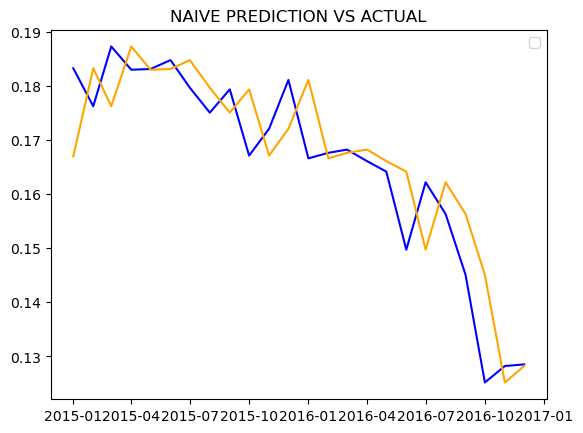

In [221]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,y_pred_naive,color='orange')
plt.title("NAIVE PREDICTION VS ACTUAL")
plt.legend()
plt.show()

C:\Users\owner's\AppData\Local\Temp\ipykernel_11860\2495843543.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


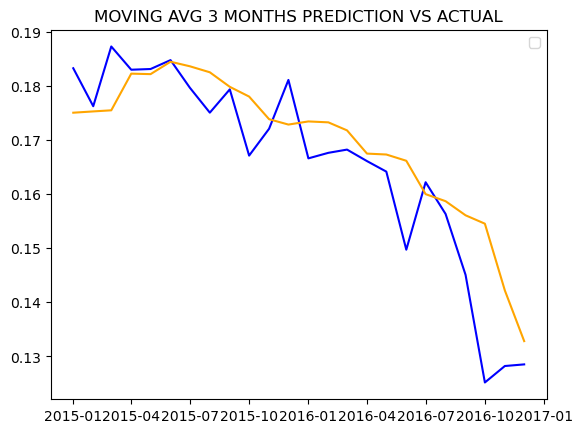

In [222]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,y_pred_ma3,color='orange')
plt.title("MOVING AVG 3 MONTHS PREDICTION VS ACTUAL")
plt.legend()
plt.show()

C:\Users\owner's\AppData\Local\Temp\ipykernel_11860\827399643.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


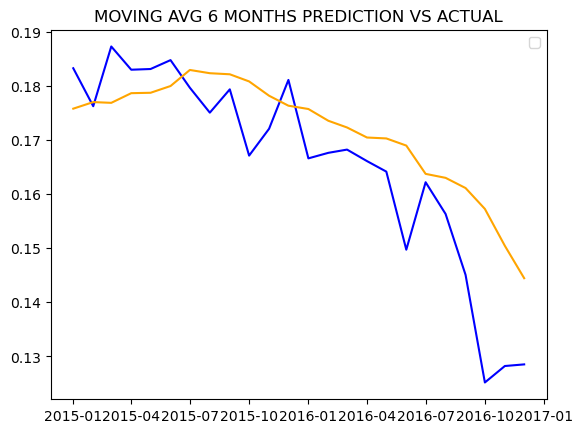

In [223]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,y_pred_ma6,color='orange')
plt.title("MOVING AVG 6 MONTHS PREDICTION VS ACTUAL")
plt.legend()
plt.show()

# ARIMA MODELS

In [224]:
from src.models import arima_model as am

In [225]:
train.head()

,total_loans,total_defaults,default_rate
issue_month,,,
2007-06-01,24,3,0.125000
2007-07-01,63,7,0.111111
2007-08-01,74,20,0.270270
2007-09-01,53,13,0.245283
2007-10-01,105,34,0.323810


In [226]:
model_100=am.arima_train(train["default_rate"],1,0,0)

C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [227]:
model_100_forecast=am.arima_forecast(model_100,test["default_rate"])

In [228]:
rmse_arima100,mae_arima100,mape_arima100=mt.evaluate_model(test["default_rate"],model_100_forecast)

In [229]:
metrics_arima100=[rmse_arima100,mae_arima100,mape_arima100]

In [230]:
evaluation_df["ARIMA(1,0,0)"]=pd.Series(metrics_arima100,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3,MA6,"ARIMA(1,0,0)"
RMSE,0.008974,0.009251,0.011536,0.017849
MAE,0.007011,0.006503,0.008902,0.014261
MAPE,0.043621,0.042823,0.059066,0.091761


In [231]:
model_200=am.arima_train(train["default_rate"],2,0,0)

C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [232]:
model_200_forecast=am.arima_forecast(model_200,test["default_rate"])

In [233]:
rmse_arima200,mae_arima200,mape_arima200=mt.evaluate_model(test["default_rate"],model_200_forecast)

In [234]:
metrics_arima200=[rmse_arima200,mae_arima200,mape_arima200]

In [235]:
evaluation_df["ARIMA(2,0,0)"]=pd.Series(metrics_arima200,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3,MA6,"ARIMA(1,0,0)","ARIMA(2,0,0)"
RMSE,0.008974,0.009251,0.011536,0.017849,0.017352
MAE,0.007011,0.006503,0.008902,0.014261,0.013882
MAPE,0.043621,0.042823,0.059066,0.091761,0.089415


In [236]:
model_101=am.arima_train(train["default_rate"],1,0,1)

C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [237]:
model_101_forecast=am.arima_forecast(model_101,test["default_rate"])

In [238]:
rmse_arima101,mae_arima101,mape_arima101=mt.evaluate_model(test["default_rate"],model_101_forecast)

In [239]:
metrics_arima101=[rmse_arima101,mae_arima101,mape_arima101]

In [240]:
evaluation_df["ARIMA(1,0,1)"]=pd.Series(metrics_arima101,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3,MA6,"ARIMA(1,0,0)","ARIMA(2,0,0)","ARIMA(1,0,1)"
RMSE,0.008974,0.009251,0.011536,0.017849,0.017352,0.017403
MAE,0.007011,0.006503,0.008902,0.014261,0.013882,0.013819
MAPE,0.043621,0.042823,0.059066,0.091761,0.089415,0.089200


In [241]:
model_201=am.arima_train(train["default_rate"],2,0,1)

C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [242]:
model_201_forecast=am.arima_forecast(model_201,test["default_rate"])

In [243]:
rmse_arima201,mae_arima201,mape_arima201=mt.evaluate_model(test["default_rate"],model_201_forecast)

In [244]:
metrics_arima201=[rmse_arima201,mae_arima201,mape_arima201]

In [245]:
evaluation_df["ARIMA(2,0,1)"]=pd.Series(metrics_arima201,index=evaluation_df.index)
evaluation_df

,NAIVE,MA3,MA6,"ARIMA(1,0,0)","ARIMA(2,0,0)","ARIMA(1,0,1)","ARIMA(2,0,1)"
RMSE,0.008974,0.009251,0.011536,0.017849,0.017352,0.017403,0.017516
MAE,0.007011,0.006503,0.008902,0.014261,0.013882,0.013819,0.014173
MAPE,0.043621,0.042823,0.059066,0.091761,0.089415,0.089200,0.090930


# PLOT ARIMA VS ACTUAL GRAPHS

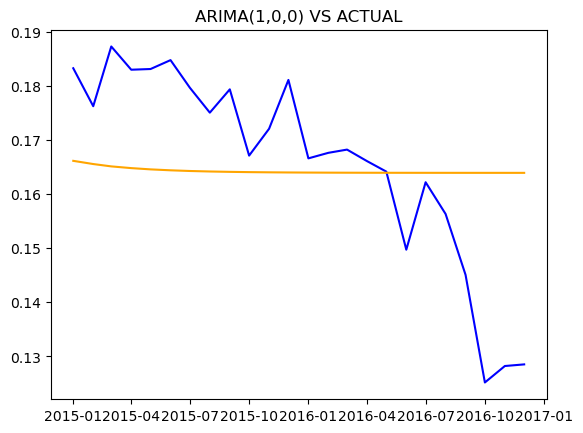

In [246]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,model_100_forecast,color='orange')
plt.title("ARIMA(1,0,0) VS ACTUAL")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\ARIMA_100_VS_ACTUAL.png", dpi=300, bbox_inches="tight")
plt.show()

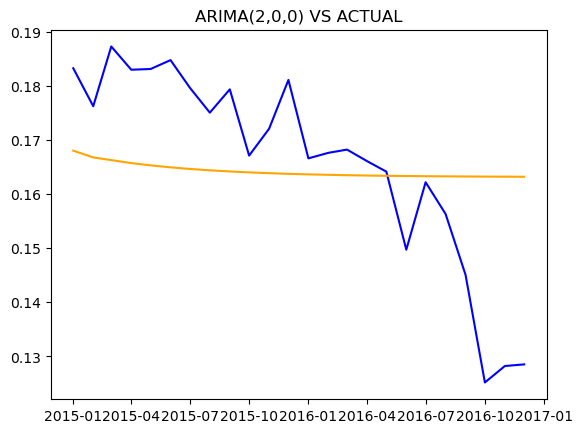

In [247]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,model_200_forecast,color='orange')
plt.title("ARIMA(2,0,0) VS ACTUAL")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\ARIMA_200_VS_ACTUAL.png", dpi=300, bbox_inches="tight")
plt.show()

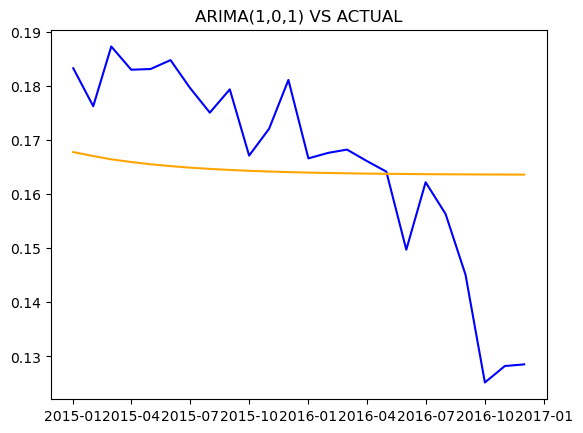

In [248]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,model_101_forecast,color='orange')
plt.title("ARIMA(1,0,1) VS ACTUAL")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\ARIMA_101_VS_ACTUAL.png", dpi=300, bbox_inches="tight")
plt.show()

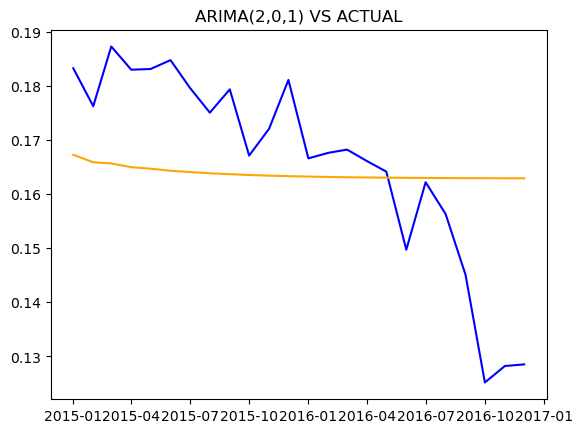

In [249]:
plt.plot(test["default_rate"].index,test["default_rate"],color='blue')
plt.plot(test["default_rate"].index,model_201_forecast,color='orange')
plt.title("ARIMA(2,0,1) VS ACTUAL")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\ARIMA_201_VS_ACTUAL.png", dpi=300, bbox_inches="tight")
plt.show()

# EXPORT THE REQUIRED DATASETS

In [250]:
evaluation_df.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\model_comparison_baselines_arima.csv")

In [251]:
y_pred_naive.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_naive.csv",index=False)
y_pred_ma3.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_ma3.csv",index=False)
y_pred_ma6.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_ma6.csv",index=False)
model_100_forecast.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_arima100.csv",index=False)
model_200_forecast.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_arima200.csv",index=False)
model_101_forecast.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_arima101.csv",index=False)
model_201_forecast.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\predictions_arima201.csv",index=False)

# SUMMARY

## C) Baseline Model Performance

Three baseline forecasting approaches were evaluated on the monthly default rate time series using a train period up to **Dec-2014** and a test period covering **2015–2016**.

**Naive Forecast**
- The naive model assumes the next month's default rate equals the most recent observed value.
- This model performed surprisingly well, achieving low RMSE and MAPE.
- The strong performance indicates that the default rate series exhibits **high short-term persistence**.

**Moving Average (3 months)**
- The MA(3) model smooths short-term fluctuations by averaging the previous three months.
- This approach slightly improved **MAE and MAPE**, suggesting that minor noise reduction can improve predictive stability.
- However, the improvement over the naive model is small.

**Moving Average (6 months)**
- The MA(6) model produced worse performance across all metrics.
- A longer averaging window causes the model to **react slowly to changes**, especially when the default rate trend shifts.
- This results in delayed forecasts and larger prediction errors.

Overall, the baseline models reveal that the default rate series is **highly persistent with relatively smooth transitions**, making simple short-memory models surprisingly competitive.

---

## D) ARIMA Results

Several ARIMA models were evaluated, including:

- ARIMA(1,0,0)
- ARIMA(2,0,0)
- ARIMA(1,0,1)
- ARIMA(2,0,1)

These models were trained using data up to **Dec-2014** and used to generate **multi-step forecasts** covering the entire 2015–2016 period.

The ARIMA models performed worse than the baseline models in this evaluation. This outcome is expected because the models were asked to generate **long multi-step forecasts without incorporating newly observed data**. As the forecast horizon increases, small prediction errors accumulate, causing forecasts to drift away from the actual series.

In contrast, the baseline models used **rolling one-step predictions**, where each new forecast incorporates the most recent observed value, resulting in more accurate short-term predictions.

To provide a fair comparison between statistical models and baselines, the next stage of the project will implement **walk-forward (rolling) validation**, where the ARIMA model is re-estimated as new observations become available.

---

## E) Key Insight

The strong performance of the naive model suggests that the portfolio default rate exhibits **significant short-term autocorrelation**, meaning that recent observations contain substantial predictive information about the next period.

This finding is consistent with the earlier time-series diagnostics:

- The **ACF plot** showed strong lag-1 correlation.
- The **PACF plot** suggested a dominant autoregressive component.
- The **ADF test** confirmed that the series is stationary.

Together, these results indicate that the default rate likely follows an **autoregressive structure**, making ARIMA-type models appropriate for forecasting when evaluated using a realistic rolling forecast framework.

The next stage of the project will therefore focus on **walk-forward backtesting** to evaluate ARIMA models under conditions that better reflect real-world portfolio monitoring.